## Setup

In [1]:
import os
import optuna
from dotenv import load_dotenv
from sklearn.metrics import f1_score, recall_score, fbeta_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

from src.py_src import util
from src.py_src.models import SpecialistMXModel

C:\Users\Eduardo\BES\IC\Solar_Flares\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

slided_df_path = os.path.join(os.getenv("SLIDED_DFS_CSV_PATH"), "data_slided_V4.parquet")
target_class = 'target_class_in_24h'
target_flux = 'target_flux_in_24h'
target_columns = [target_class, target_flux]

df_model_input = util.create_df_model_input_opt(slided_df_path, target_columns, "xl_")

Carregando 46 colunas do arquivo Parquet...


## Preparing Data

In [3]:
specialist_mx_pool = df_model_input[df_model_input[target_class] > 3].copy()

specialist_mx_pool['target_log_flux'] = np.log10(specialist_mx_pool[target_flux] + 1e-9)
specialist_mx_pool = specialist_mx_pool.drop(columns=[target_class])

train_pct = 0.7
val_pct = (1-train_pct)/2

data = util.prepare_data(
    df_model_input=specialist_mx_pool,
    target_class_col='target_log_flux',
    lambda_function=lambda lb: lb,
    train_pct=train_pct,
    val_pct=val_pct,
    target_flux_col=target_flux
)

## Discovery Model

In [4]:
discovery_model = SpecialistMXModel(
    params={
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 5,
        'n_jobs': -1,
        'random_state': 42,
        'objective': 'reg:squarederror'
    }
)

In [5]:
selected_features = discovery_model.discover_top_features(
    x=data['x']['train'],
    y=data['y']['train'],
    cumulative_threshold=0.95
)

--- Quick Scan (Discovery Mode) ---
Quick Scan concluído. 31 features selecionadas (de 44).


In [6]:
CUTOFF = -4.0

## Hyperparameter Tuning (Optuna)

In [7]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'n_estimators': 1000,
        'random_state': 1502,
        'n_jobs': -1,
        'early_stopping_rounds': 50,
        'device': 'cuda',

        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = SpecialistMXModel(params=params, features_to_keep=selected_features)

    model.fit(
        x=data['x']['train'],
        y=data['y']['train'],
        eval_set=[(data['x']['val'], data['y']['val'])],
        verbose=False
    )

    y_pred_log_flux_ = model.predict(data['x']['val'])
    y_pred_class_ = (y_pred_log_flux_ >= CUTOFF).astype(int)
    y_true_class_ = (data['y']['val'] >= CUTOFF).astype(int)

    score = fbeta_score(y_true_class_, y_pred_class_, pos_label=1, beta=2)

    return score

In [8]:
study = optuna.create_study(direction='maximize')
print("\nIniciando tuning...")
study.optimize(objective, n_trials=500)

print(f"\nBest Score: {study.best_value:.4f}")
best_params = study.best_params

best_params.update({
    'n_estimators': 1000,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 1502,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'device': 'cuda'
})

[I 2026-02-07 16:21:53,196] A new study created in memory with name: no-name-fc9b2e75-e5dd-4346-bd42-de429da4334f



Iniciando tuning...


C:\Users\Eduardo\BES\IC\Solar_Flares\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [16:21:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-02-07 16:21:54,079] Trial 0 finished with value: 0.0 and parameters: {'max_depth': 6, 'learning_rate': 0.034894068930871755, 'subsample': 0.8752810800906319, 'colsample_bytree': 0.8029623830935755, 'gamma': 0.6148449177418513, 'min_child_weight': 10, 'max_delta_step': 6}. Best is trial 0 with value: 0.0.
[I 2026-02-07 16:21:54,601] Trial 1 finished with value: 0.0 and parameters: {'max_depth': 


Best Score: 0.0191


In [9]:
final_model = SpecialistMXModel(params=study.best_params, features_to_keep=selected_features)
final_model.fit(
    x=data['x']['train'],
    y=data['y']['train'],
    eval_set=[(data['x']['val'], data['y']['val'])]
)

[0]	validation_0-rmse:0.35404
[1]	validation_0-rmse:0.35143
[2]	validation_0-rmse:0.34913
[3]	validation_0-rmse:0.34742
[4]	validation_0-rmse:0.34540
[5]	validation_0-rmse:0.34400
[6]	validation_0-rmse:0.34267
[7]	validation_0-rmse:0.34165
[8]	validation_0-rmse:0.34099
[9]	validation_0-rmse:0.34046
[10]	validation_0-rmse:0.33991
[11]	validation_0-rmse:0.33892
[12]	validation_0-rmse:0.33857
[13]	validation_0-rmse:0.33811
[14]	validation_0-rmse:0.33771
[15]	validation_0-rmse:0.33737
[16]	validation_0-rmse:0.33712
[17]	validation_0-rmse:0.33677
[18]	validation_0-rmse:0.33637
[19]	validation_0-rmse:0.33616
[20]	validation_0-rmse:0.33623
[21]	validation_0-rmse:0.33622
[22]	validation_0-rmse:0.33606
[23]	validation_0-rmse:0.33592
[24]	validation_0-rmse:0.33608
[25]	validation_0-rmse:0.33599
[26]	validation_0-rmse:0.33597
[27]	validation_0-rmse:0.33616
[28]	validation_0-rmse:0.33596
[29]	validation_0-rmse:0.33621
[30]	validation_0-rmse:0.33639
[31]	validation_0-rmse:0.33637
[32]	validation_0-

,params,"{'colsample_bytree': 0.8330517965982389, 'gamma': 4.076146192668738, 'learning_rate': 0.10248311228526388, 'max_delta_step': 0, ...}"
,features_to_keep,"['xl_std_24h', 'xl_std_7D', ...]"


## Results

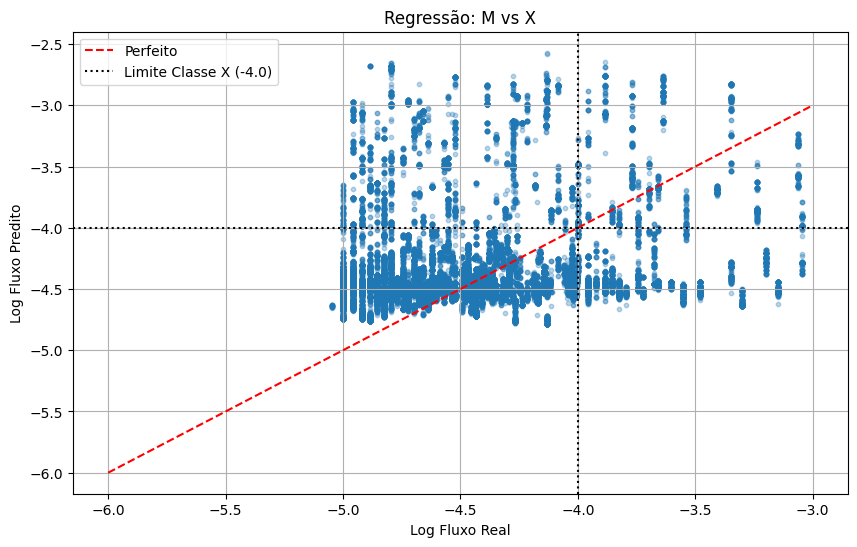

In [10]:
y_pred_log_flux = final_model.predict(data['x']['test'])
y_pred_class = (y_pred_log_flux >= CUTOFF).astype(int)
y_true_class = (data['y']['test'] >= CUTOFF).astype(int)

plt.figure(figsize=(10,6))
plt.scatter(data['y']['test'], y_pred_log_flux, alpha=0.3, s=10)
plt.plot([-6, -3], [-6, -3], 'r--', label='Perfeito') # Linha de identidade
plt.axvline(-4.0, color='k', linestyle=':', label='Limite Classe X (-4.0)')
plt.axhline(-4.0, color='k', linestyle=':')
plt.xlabel('Log Fluxo Real')
plt.ylabel('Log Fluxo Predito')
plt.title('Regressão: M vs X')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
print("--- Relatório de Classificação (Derivado da Regressão) ---")
print(classification_report(y_true_class, y_pred_class, target_names=['M', 'X']))

--- Relatório de Classificação (Derivado da Regressão) ---
              precision    recall  f1-score   support

           M       0.88      0.89      0.88     33848
           X       0.35      0.33      0.34      6070

    accuracy                           0.80     39918
   macro avg       0.61      0.61      0.61     39918
weighted avg       0.80      0.80      0.80     39918



In [12]:
fig, summary = final_model.analyze_flux_errors(
    data['x']['test'], data['y']['test'],
    flux_values=data['flux']['test'],
    cutoff=CUTOFF
)
display(summary)

Outcome,TN (Correct Rejection),FP (False Alarm),FP Rate (%),TP (Hit),FN (Miss),FN Rate (%)
Zone,,,,,,
1. Safe/Low Zone,30044,3804,11.2,259,138,34.8
3. Danger/High Zone,0,0,NaN,1758,3915,69.0


In [13]:
summary.to_csv()

'Zone,TN (Correct Rejection),FP (False Alarm),FP Rate (%),TP (Hit),FN (Miss),FN Rate (%)\r\n1. Safe/Low Zone,30044,3804,11.2,259,138,34.8\r\n3. Danger/High Zone,0,0,,1758,3915,69.0\r\n'

In [14]:
error_report = final_model.analyze_error_distribution(
    x=data['x']['test'],
    y_true=data['y']['test'],
    flux_values=data['flux']['test'],
    cutoff = CUTOFF
)
display(error_report)

,FN (Miss),FP (False Alarm),FN (Miss) Avg Flux,FP (False Alarm) Avg Flux
SolarClass,,,,
M (1.0 - 9.9),0,3804,-,3.43e-05
X (> M10),4053,0,2.49e-04,-


In [15]:
error_report.to_csv()

'SolarClass,FN (Miss),FP (False Alarm),FN (Miss) Avg Flux,FP (False Alarm) Avg Flux\r\nM (1.0 - 9.9),0,3804,-,3.43e-05\r\nX (> M10),4053,0,2.49e-04,-\r\n'

## Features Importance

In [16]:
features_importance = final_model.get_feature_importance()
features_importance

,feature,importance,cumulative_importance
0,xl_std_24h,0.103633,0.103633
3,xl_integ_24h,0.074577,0.178210
1,xl_std_7D,0.061380,0.239590
11,xl_std_12h,0.060045,0.299635
2,xl_integ_7D,0.054250,0.353885
25,xl_max_1h,0.051076,0.404961
22,xl_std_6h,0.046125,0.451086
6,xl_mean_7D,0.045065,0.496151
15,xl_log_mean_12h,0.042495,0.538646
5,xl_log_mean_7D,0.041512,0.580158


## Export

In [17]:
# specialist_mx_dir = os.getenv('SPECIALIST_MX_MODELS_PATH')
# save_path = os.path.join(specialist_mx_dir, '24h/specialist_mx_24h_v1.joblib')
# final_model.save(save_path)